In [514]:
## IMPORTS

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import ( train_test_split,
                                      GridSearchCV,
                                      TunedThresholdClassifierCV)

from sklearn.preprocessing import ( StandardScaler,
                                    OneHotEncoder, 
                                    PolynomialFeatures) 

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import ( RandomForestClassifier,
                               GradientBoostingClassifier

)
from sklearn.metrics import (accuracy_score,
                            precision_score,
                            recall_score,
                            f1_score,
                            confusion_matrix,
                            classification_report,
                            roc_auc_score,
                            precision_recall_curve,
                            ConfusionMatrixDisplay,
                            RocCurveDisplay,
                            PrecisionRecallDisplay)

import joblib


In [515]:
##importing data set
df = pd.read_csv("../data/machine_failure_dataset_cleaned.csv")

# **ANALYSING, CLEANING & EDA**

ANALYSIS

In [516]:
df.head()

,product_ID,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
0,H29424,H,298.4,308.9,1782.0,23.9,24,0,0,0,0
1,H29425,H,298.6,309.1,1423.0,44.3,29,0,0,0,0
2,H29432,H,298.8,309.2,1306.0,54.5,50,0,0,0,0
3,H29434,H,298.9,309.3,1375.0,42.7,58,0,0,0,0
4,H29441,H,299.1,309.4,1811.0,24.6,77,0,0,0,0


In [517]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_ID             1081 non-null   str    
 1   product_type           1081 non-null   str    
 2   air_temperature_k      1072 non-null   float64
 3   process_temperature_k  1075 non-null   float64
 4   rotational_speed_rpm   1080 non-null   float64
 5   torque_nm              1074 non-null   float64
 6   tool_wear_min          1081 non-null   int64  
 7   machine_failure        1081 non-null   int64  
 8   tool_wear_failure      1081 non-null   int64  
 9   power_failure          1081 non-null   int64  
 10  overstrain_failure     1081 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 100.4 KB


In [518]:
df.describe()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
count,1072.000000,1075.000000,1080.000000,1074.000000,1081.000000,1081.000000,1081.000000,1081.000000,1081.000000
mean,297.426679,308.288744,1539.454630,41.476164,108.653099,0.022202,0.000925,0.012951,0.009251
std,0.940060,0.976013,181.580554,29.685232,63.557417,0.147407,0.030415,0.113115,0.095779
min,295.300000,305.700000,1168.000000,4.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,296.800000,307.800000,1424.750000,33.200000,54.000000,0.000000,0.000000,0.000000,0.000000
50%,297.500000,308.400000,1503.000000,40.100000,110.000000,0.000000,0.000000,0.000000,0.000000
75%,298.100000,309.000000,1611.000000,46.475000,163.000000,0.000000,0.000000,0.000000,0.000000
max,299.100000,310.200000,2874.000000,500.000000,240.000000,1.000000,1.000000,1.000000,1.000000


In [519]:
df.shape

(1081, 11)

In [520]:
df.columns

Index(['product_ID', 'product_type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'tool_wear_failure',
       'power_failure', 'overstrain_failure'],
      dtype='str')

In [521]:
## There is a huge imbalance, **MUST DO CLASS=BALANCED**

df["machine_failure"].value_counts()

machine_failure
0    1057
1      24
Name: count, dtype: int64

In [522]:
df.isnull().sum()

product_ID               0
product_type             0
air_temperature_k        9
process_temperature_k    6
rotational_speed_rpm     1
torque_nm                7
tool_wear_min            0
machine_failure          0
tool_wear_failure        0
power_failure            0
overstrain_failure       0
dtype: int64

CLEANING


In [523]:
## SQL handled most of the cleaning, PYTHON will deal with NULL values(simple imputer, during pipeline building) and Outliers(during EDA)

In [524]:
##REMOVING unwanted columns, product_ID is only an identifier and it has no predictive value.

df = df.drop("product_ID", axis=1)

In [525]:
## REMOVING machine_failure types to prevent data leakage

In [526]:
df = df.drop(columns=[
    "tool_wear_failure",
    "power_failure",
    "overstrain_failure"
])

**EXPLORITORY DATA ANALYSIS**

In [527]:
## Separating numerical and categorical columns

numerical_columns = ["air_temperature_k",
                     "process_temperature_k",
                     "rotational_speed_rpm",
                     "torque_nm",
                     "tool_wear_min"
                     

]
categorical_columns = [
                        "product_type",
    
]

DISTRIBUTION
- help up understand how the data is distributed

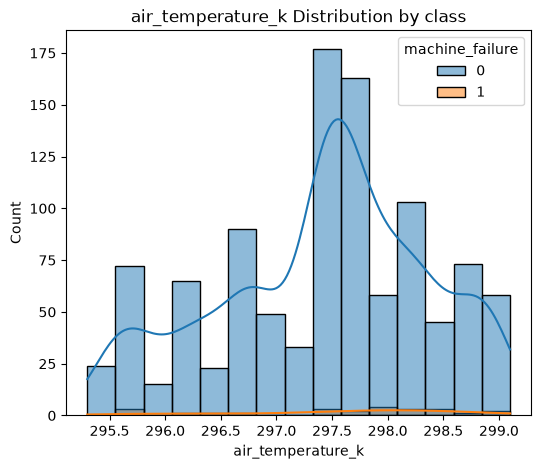

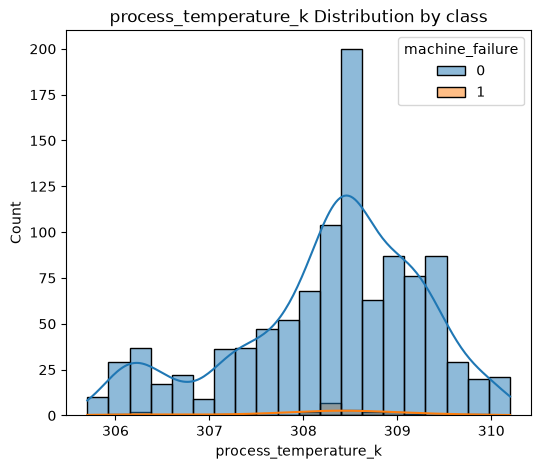

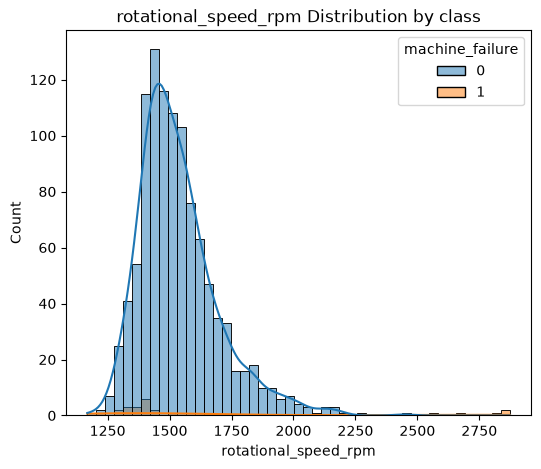

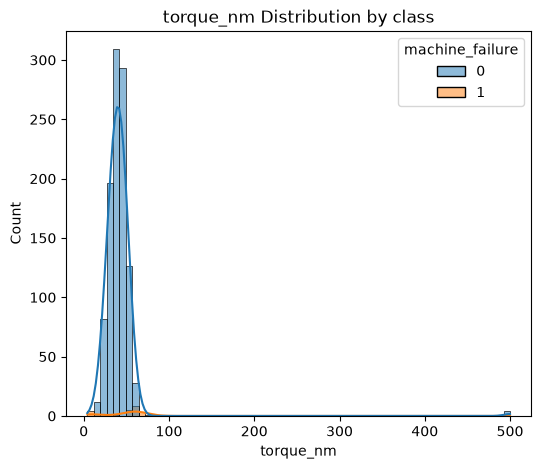

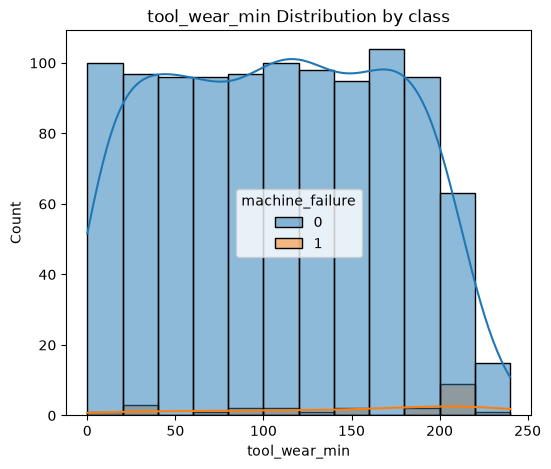

In [528]:
## Histogram (for numerical values)

for column in numerical_columns:
    plt.figure(figsize=(6,5))

    sns.histplot(
        data=df,
        x=column,
        hue="machine_failure",
        kde = True   
    )

    plt.title(f"{column} Distribution by class")
    plt.show()


Observation:

- air_temperature_k: shows a multimodal shape and failure are rare however there is a slight increan of failures forming a bell shape from 296.7 to 299
  
- process_temperature_k: multimodal and left-skewed, failures are rare however there is a slight increase of failures forming a bell shape from 307.5 to 309.5 of failures between
 
- rotational_speed_rpm: right skewed with a few outliers, failures are rare however they show a small left skewed shape in the beggining of the graph
- torque_nm: bell shape, left skewed a little bit, failures are still rare however they show a small bell shape from 40 to 90
- tool_wear_min: rectangle shape, right skewed a little, failures are rare howeever they form a small left skewed graph

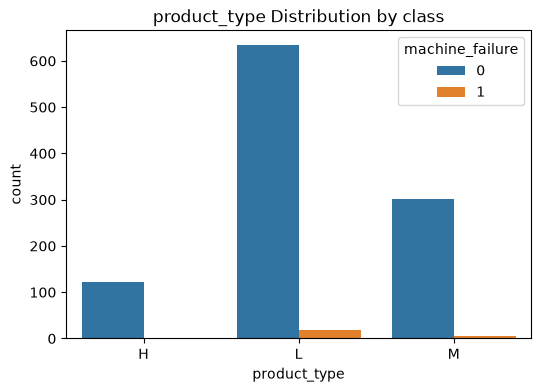

In [529]:
## Count plot(for categorical values)

for column in categorical_columns:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=column,
        hue="machine_failure"
    )

    plt.title(f"{column} Distribution by class")
    plt.show()




Observation:

- product_type: machine failure are less common for the product type H (High) and most common for product type L (Low), Medium (M) failures are less than product type L and more than product type H. 


OUTLIER DETECTION
- While observing the distribution graphs we have discoverd that some numerical columns may contain outliers

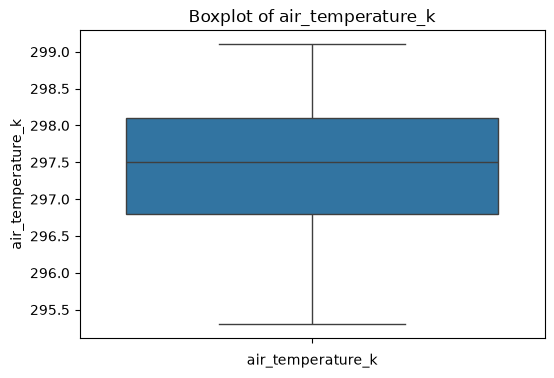

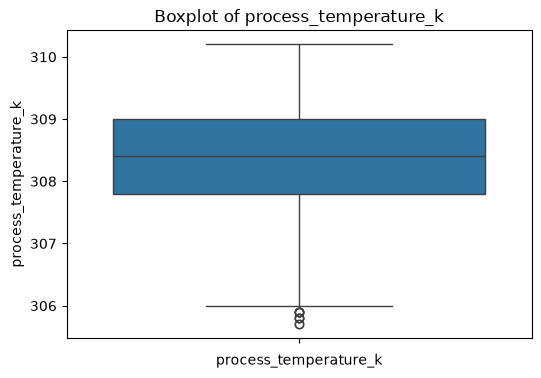

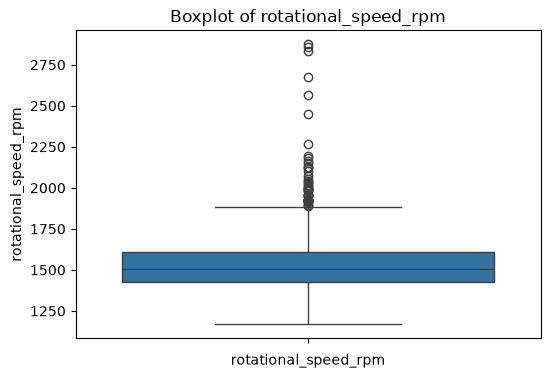

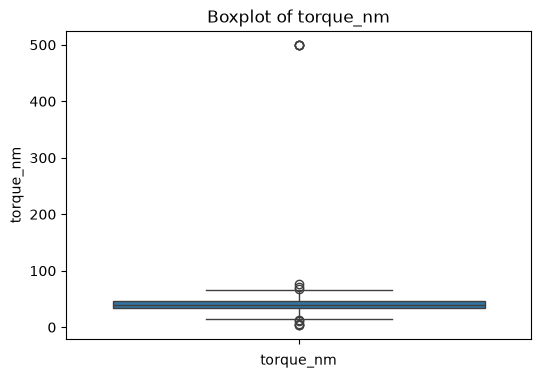

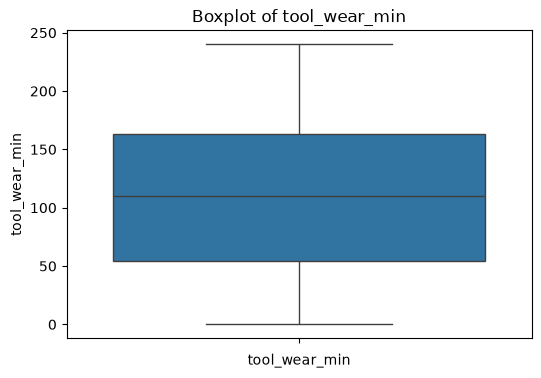

In [530]:
## Boxplot to see weather a feature contains outliers
for column in numerical_columns:
    plt.figure(figsize=(6,4))

    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(f'{column}')
    plt.show()

Observation:

- air_temperature_k: all values are within the whiskers, indicating that no outliers were detected
  
- process_temperature_k: a few values are clustered close to each other appear below the lower whisker, since these values are not extremely isolated this could suggest a natural variation

- rotational_speed_rpm: a few values are clustered close to each other above the upper whisker, these values do not appear to be isolated and this suggest a natural variation

- torque_nm: there are a few values that appear below the lower whisker and above the upper whisker these values are clustered close to each other, however ther is a single value that is isolated way above the other values above the upper whisker. this value was identified as an artificially introduced value during data preparation, therefore it will me removed

- tool_wear_min: all values are within the whiskers, indicating that no outliers were detected

REMOVING OUTLIERS

In [531]:
## Removing the artificially introduced torque value

df = df[df["torque_nm"] < 500]

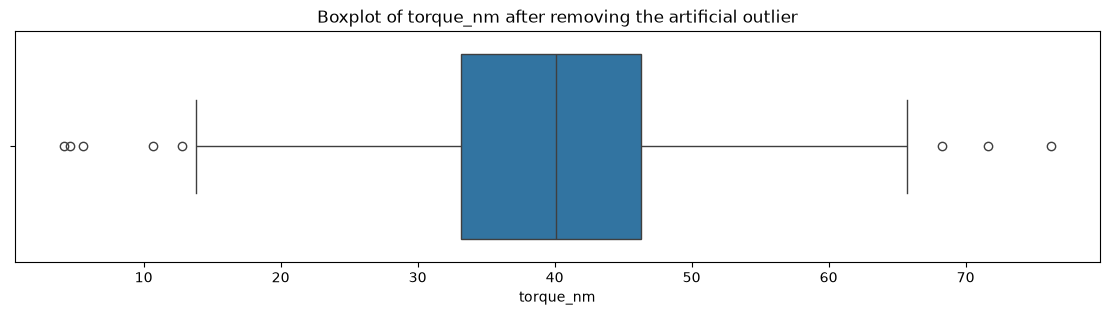

In [532]:
plt.figure(figsize=(14,3))
sns.boxplot(x=df["torque_nm"])
plt.title("Boxplot of torque_nm after removing the artificial outlier")
plt.show()

CORRELATION ANALYSIS

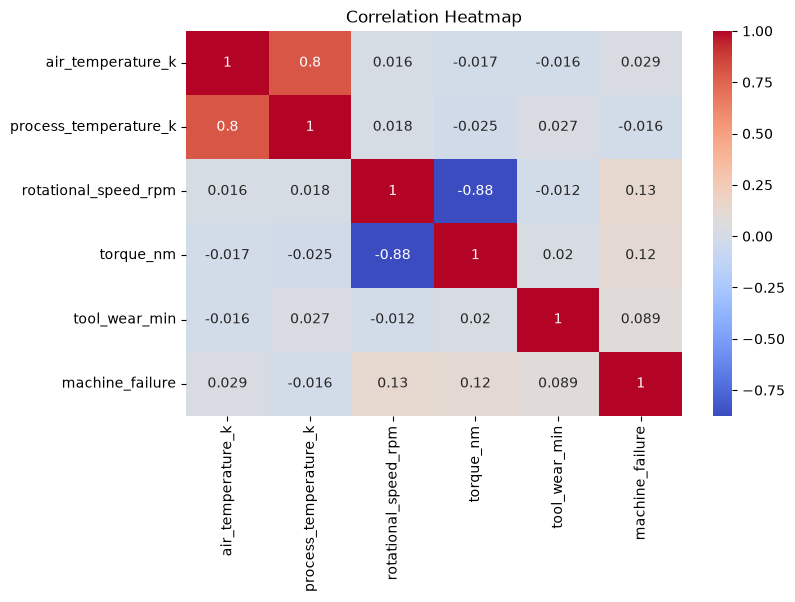

In [533]:
## Correlation analysis for numerical values
## Heatmap 

plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only = True),
    annot = True,
    cmap = "coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Observation:

- process_temperature_k and air_temperature have a strong positive correlation of 0.8, these two features are related so we will perfome feature engineering on them

- rotational_speed_rpm and torque_nm have a strong negative correlation of -0.88, meaning they have an inverse relationship 

- the remaining features do not show any strong correlation and were therefore retained for model development

FEATURE ENGINEERING

In [534]:
## 

df["machine_operating_process_k"] = df["process_temperature_k"] - df["air_temperature_k"]

In [535]:
## 

df["machanical_power"] = df["torque_nm"] * df["rotational_speed_rpm"]

In [536]:
df.head()


,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,machine_operating_process_k,machanical_power
0,H,298.4,308.9,1782.0,23.9,24,0,10.5,42589.8
1,H,298.6,309.1,1423.0,44.3,29,0,10.5,63038.9
2,H,298.8,309.2,1306.0,54.5,50,0,10.4,71177.0
3,H,298.9,309.3,1375.0,42.7,58,0,10.4,58712.5
4,H,299.1,309.4,1811.0,24.6,77,0,10.3,44550.6


# **MODEL BUILDING**

In [537]:
## defining X and y

X = df.drop("machine_failure", axis=1)
y = df["machine_failure"]

TRAIN TEST SPLIT

In [538]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

## LOGISTIC REGRESSION PIPELINE BUILDING and Preprocessing

In [539]:
## RENEWING (Separating numerical and categorical columns)

numerical_columns = ["air_temperature_k",
                     "process_temperature_k",
                     "torque_nm",
                     "tool_wear_min",
                     "machine_operating_process_k",
                     "machanical_power"
]

categorical_columns = [
                        "product_type",
]

In [540]:
numerical_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy= "median")),
   ("scaler", StandardScaler()),
   ("poly", PolynomialFeatures( include_bias=False))


])

In [541]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

PREPROCESSOR


In [542]:
## Preprocessed data: prepared, cleaned, consistent and ready for machine learning to learn from

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

### LOGISTIC REGRESSION MODELS

In [543]:
## parameters and model

models = {
    "LogisticRegression": {
        "model": LogisticRegression(class_weight="balanced", random_state=42, max_iter=100),
        "params": {
            "model__C": [ 0.01, 0.05,0.1],
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"],
            "preprocessor__numerical__poly__degree": [1, 2]
            
        }
    }
}

In [544]:
for model, config in models.items():
    
    logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor ),
    ("model", config["model"])
    ])

In [545]:
logistic_search = GridSearchCV(
                                logistic_pipeline, 
                                config["params"], 
                                n_jobs=-1,
                                cv=5, 
                                scoring="recall"
)

logistic_search.fit(X_train, y_train)

c:\Users\Siphesihle\Documents\manufacturing-quality-intelligence-system\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Siphesihle\Documents\manufacturing-quality-intelligence-system\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.05, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear'], 'preprocessor__numerical__poly__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for calla

In [546]:
best_logistic_params = logistic_search.best_params_
print(best_logistic_params)

best_logistic_model = logistic_search.best_estimator_
print(best_logistic_model)

{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'preprocessor__numerical__poly__degree': 2}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['air_temperature_k',
                                                   'process_temperature_k',
                                                   'torque_nm', 'tool_wear_min',
                              

### EVALUATION

In [547]:
y_pred = best_logistic_model.predict(X_test)

In [548]:
## some evaluation metrics require probabilities

probabilities = best_logistic_model.predict_proba(X_test)[:,1]

In [549]:

def evaluate(y_test, y_pred, probabilities):
  results = {
      "accuracy": accuracy_score(y_test, y_pred),
      "precision": precision_score(y_test, y_pred),
      "recall": recall_score(y_test, y_pred),
      "f1": f1_score(y_test, y_pred),
      "roc_auc": roc_auc_score(y_test, probabilities),
      "confusion_matrix": confusion_matrix (y_test, y_pred),
      "classification_report": classification_report(y_test, y_pred)
  }

  return results

In [550]:
evaluate(y_test, y_pred, probabilities)

{'accuracy': 0.8691588785046729,
 'precision': 0.15151515151515152,
 'recall': 1.0,
 'f1': 0.2631578947368421,
 'roc_auc': 0.983732057416268,
 'confusion_matrix': array([[181,  28],
        [  0,   5]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      0.87      0.93       209\n           1       0.15      1.00      0.26         5\n\n    accuracy                           0.87       214\n   macro avg       0.58      0.93      0.60       214\nweighted avg       0.98      0.87      0.91       214\n'}

Confusion matrix

- True positives: as observed previosly the model has a few failures and it has captured most of them
- False positives: a few or no false machine_failures where predicted

- True negatives: all or most machine_failures were captured
- False negatives: a few non-machine_failures where predicted to be machine_failures which is better than getting false negatives

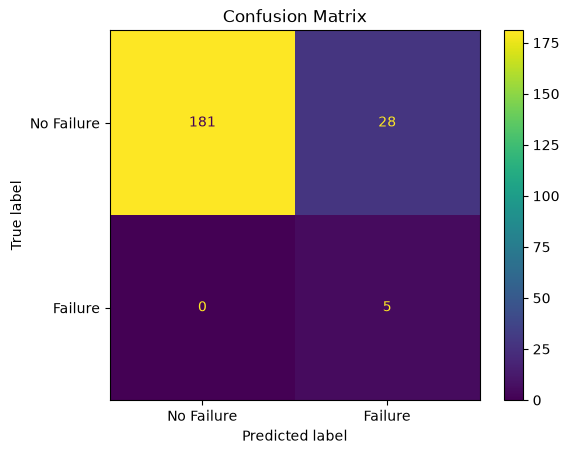

In [551]:
ConfusionMatrixDisplay.from_estimator(
    best_logistic_model, 
    X_test, 
    y_test,
    display_labels = ["No Failure", "Failure"]
    )
plt.title("Confusion Matrix")
plt.show()

ROC Curve

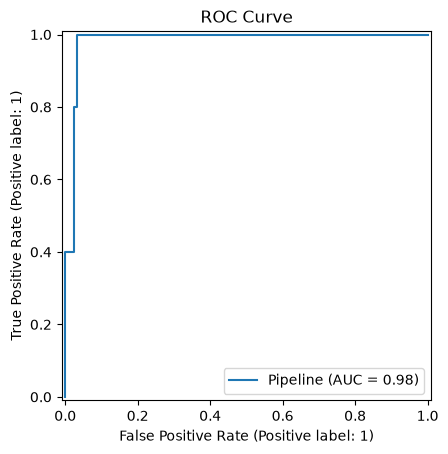

In [552]:
RocCurveDisplay.from_estimator(
    best_logistic_model,
    X_test,
    y_test
)
plt.title("ROC Curve")
plt.show()

Precision-Recall Curve

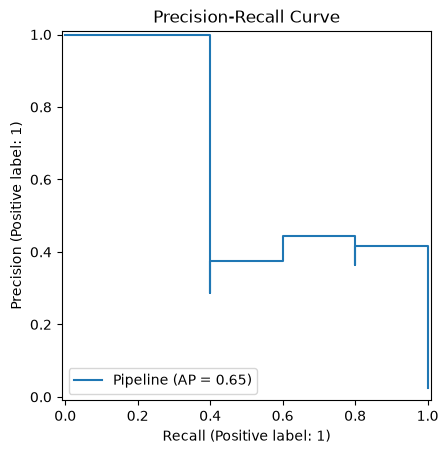

In [553]:
PrecisionRecallDisplay.from_estimator(
    best_logistic_model,
    X_test,
    y_test
    )
plt.title("Precision-Recall Curve")
plt.show()

## TREES-BASED PIPELINE and Preprocessing

In [554]:
tree_numerical_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy= "median"))
])

In [555]:
tree_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy= "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [556]:
tree_preprocessor = ColumnTransformer([
    ("tree_numerical", tree_numerical_pipeline, numerical_columns),
    ("tree_categorical", tree_categorical_pipeline, categorical_columns)
])

### TREES-BASED MODELS

In [557]:
tree_models = {
    "DecisionTreeClassifier": {
        "tree_model": DecisionTreeClassifier(random_state=42),
        "tree_params": {
            "tree_model__max_depth": [3, 5, 10, None],
            "tree_model__min_samples_split": [2,5,10],
            "tree_model__min_samples_leaf": [1,2,4]
        }
    },

    "RandomForestClassifier": {
        "tree_model": RandomForestClassifier(random_state=42),
        "tree_params": {
            "tree_model__n_estimators": [100,200],
            "tree_model__max_depth": [10,20, None],
            "tree_model__min_samples_split": [2,5],
            "tree_model__min_samples_leaf": [1,2]
        }
    },

    "GradientBoostingClassifier": {
        "tree_model": GradientBoostingClassifier(random_state=42),
        "tree_params": {
            "tree_model__n_estimators": [100,200],
            "tree_model__learning_rate": [0.01, 0.1],
            "tree_model__max_depth": [3,5]
        }
    }

}

In [558]:
for tree_model, config in tree_models.items():

    tree_pipeline = Pipeline([
        ("tree_preprocessor", tree_preprocessor),
        ("tree_model", config["tree_model"])
    ])
    

In [559]:
tree_search = GridSearchCV(
    tree_pipeline,
    config["tree_params"],
    n_jobs=-1,
    cv=5,
    scoring = "recall"
)

In [560]:
tree_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree_model__learning_rate': [0.01, 0.1], 'tree_model__max_depth': [3, 5], 'tree_model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ve

In [561]:
best_tree_params = tree_search.best_params_
(best_tree_params)

{'tree_model__learning_rate': 0.1,
 'tree_model__max_depth': 3,
 'tree_model__n_estimators': 200}

In [562]:
best_tree_model = tree_search.best_estimator_
(best_tree_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tree_preprocessor', ...), ('tree_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['product_type','air_temperature_k','process_temperature_k',..., 'tool_wear_min','machine_operating_process_k','machanical_power']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tree_numerical', ...), ('tree_categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedc

##  EVALUATION

In [563]:
tree_probabilities = best_tree_model.predict_proba(X_test)[:,1]

In [564]:
tree_y_pred = best_tree_model.predict(X_test)



In [565]:
def evaluate (y_test, tree_y_pred, tree_probabilities):
    results = {
          "accuracy": accuracy_score(y_test, tree_y_pred),
          "precision": precision_score(y_test, tree_y_pred),
          "recall": recall_score(y_test, tree_y_pred),
          "f1": f1_score(y_test, tree_y_pred),
          "roc_auc": roc_auc_score(y_test, tree_probabilities),
          "confusion_matrix": confusion_matrix (y_test, tree_y_pred),
          "classification_report": classification_report(y_test, tree_y_pred)
      }
    return results

In [566]:
evaluate (y_test, tree_y_pred, tree_probabilities)

{'accuracy': 0.9906542056074766,
 'precision': 1.0,
 'recall': 0.6,
 'f1': 0.75,
 'roc_auc': 0.999043062200957,
 'confusion_matrix': array([[209,   0],
        [  2,   3]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.99      1.00      1.00       209\n           1       1.00      0.60      0.75         5\n\n    accuracy                           0.99       214\n   macro avg       1.00      0.80      0.87       214\nweighted avg       0.99      0.99      0.99       214\n'}

Confusision Matrix

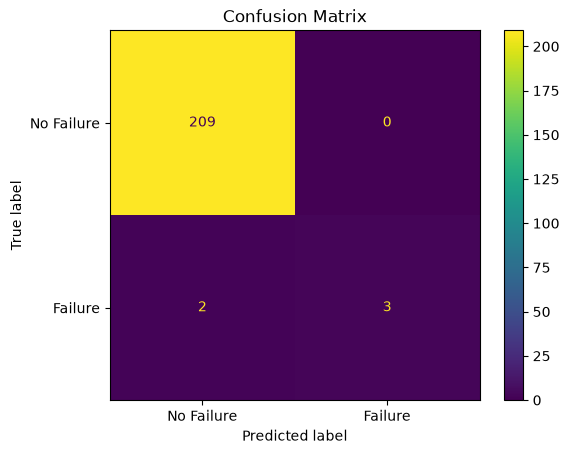

In [567]:
ConfusionMatrixDisplay.from_estimator(
    best_tree_model, 
    X_test, 
    y_test,
    display_labels=["No Failure", "Failure"])
plt.title("Confusion Matrix")
plt.show()

JOBLIB (saving model)

In [568]:
joblib.dump({"model": best_logistic_model},"machine_failure_model.joblib")

['machine_failure_model.joblib']

In [569]:
model = joblib.load("machine_failure_model.joblib")